In [16]:
#importing external dependencies
!pip install tensorflow keras

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, datasets, utils



Here, we load image data (like CIFAR-10) and normalize pixel values (0–255 → 0–1) so the model learns better.

In [18]:
#Loading Dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images = train_images / 255.0
test_images = test_images / 255.0

Building the CNN Model:<br>
- Conv2D: Detects features like edges and patterns<br>
- ReLU: Adds non-linearity (helps learn complex patterns)
- MaxPooling: Reduces image size, keeps important info
- Flatten: Converts 2D data to 1D
- Dense: Final layer that predicts the image class

In [19]:
#Building the CNN Model
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10)) # 10 classes

After this, we define:

Optimizer (e.g., Adam) → how the model learns
Loss function → how wrong predictions are measured
Metrics → accuracy tracking

In [20]:
#Compiling the Model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#Training Model
# The model learns from training images over multiple cycles (epochs).

history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 27ms/step - accuracy: 0.4540 - loss: 1.4988 - val_accuracy: 0.5498 - val_loss: 1.2792
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.5948 - loss: 1.1437 - val_accuracy: 0.6207 - val_loss: 1.0702
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.6515 - loss: 0.9949 - val_accuracy: 0.6571 - val_loss: 0.9718
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.6875 - loss: 0.8877 - val_accuracy: 0.6789 - val_loss: 0.9211
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7171 - loss: 0.8110 - val_accuracy: 0.6875 - val_loss: 0.9047
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.7382 - loss: 0.7466 - val_accuracy: 0.7001 - val_loss: 0.8653
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.7564 - loss: 0.6945 - val_accuracy: 0.6917 - val_loss: 0.8862
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.7729 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6995 - loss: 0.9362
Test Accuracy: 0.6995000243186951


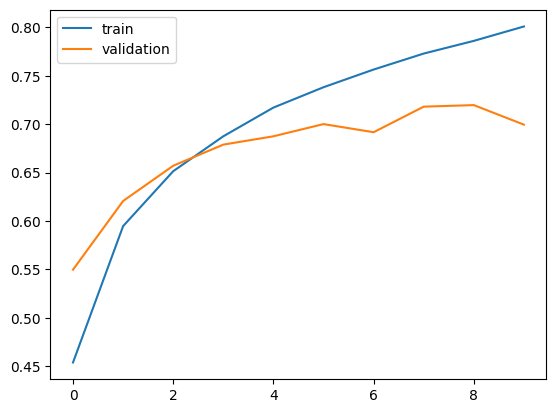

In [21]:
#testing how well the model performs on unseen images.
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

#plotting for visualizing
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'validation'])
plt.show()

**Conclusion:**<br>
Image classification using a CNN successfully learns to recognize and categorize images by extracting features like edges, shapes, and patterns. The model achieves good accuracy after training and can generalize to new images. This shows CNNs are effective for solving basic image recognition tasks.
